# Ch05.서포트 벡터 머신

**서포트 벡터 머신(Support Vector Machine,SVM)** 은 강력하면서 선형이나 비선형 분류, 회귀, 특이치 탐지에도 사용할 수 있는 다목적 머신러닝 모델이다. SVM은 중소규모의 비선형 데이터셋(수백에서 수천 개의 샘플)과 분류에서 매우 강력하다. 그러나 큰 데이터셋에서는 잘 사용하지 않는다.

먼저 SVM의 기본 아이디어와 실습을 진행 한 후, 복잡한 SVM의 이론을 살펴본다.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')  
plt.rcParams['axes.unicode_minus'] = False 


from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

---

## 5.1 선형 SVM 분류

SVM의 기본 아이디어를 다음 그림을 통해 설명한다. 해당 데이터셋은 *Iris* 데이터셋이다.

<center>

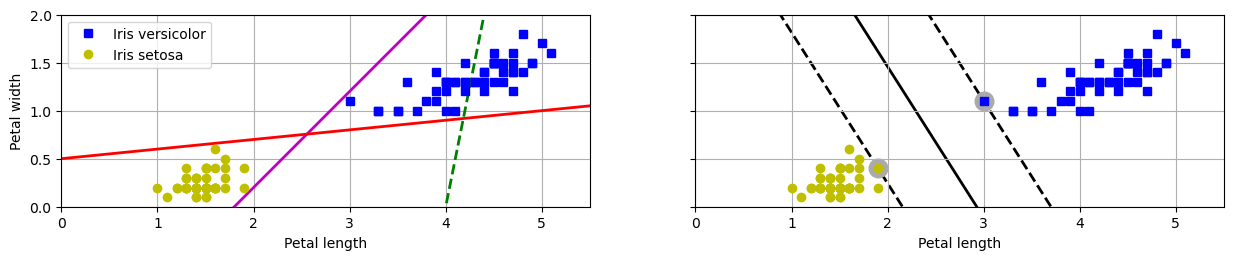

</center>

왼쪽 그래프에 임의의 3개 선형 분류기에서 만들어진 결정 경계가 보인다. 점선으로 나타난 결정 경계를 만든 모델은 클래스를 적절하게 분류하지 못하고 있다. 다른 두 모델은 훈련 세트에 완벽하게 작동한다. 하지만 **결정 경계가 너무 데이터에 가까워 새로운 샘플에 대해서는 잘 작동하지 않을 것**이다.

반면, 오른쪽 그래프에 있는 실선은 SVM 분류기의 결정 경계이다. 이 직선을 두 개의 클래스를 나누고 있을 뿐만 아니라 제일 가까운 훈련 샘플로부터 가능한 한 멀리 떨어져 있다. 즉, SVM 분류기는 **클래스 사이에 가장 폭이 넓은 도로를 찾는 것**으로 생각할 수 있다. 따라서 **Large margin classfication**라고 한다.

도로 밖에 훈련 샘플을 추가해도 결정 경계에는 전혀 영향을 미치지 않고, 경계에 위치한 샘플에 위해 전적으로 결정된다. 이런 샘플을 **서포트 벡터**라고 하며, 오른쪽 그래프의 회색 원으로 표시했다. 서포트 벡터는 모델을 결정하는 핵심 데이터 포인트들이며 **결정 경계나 예측 함수를 만드는 데 직접적인 영향**을 준다.

### 스케일 민감성

SVM은 **변수의 스케일에 민감**하다. 다음 그래프의 왼쪽은 스케일링을 하지 않은 경우와 오른쪽은 스케일링을 진행한 경우이다.

<center>

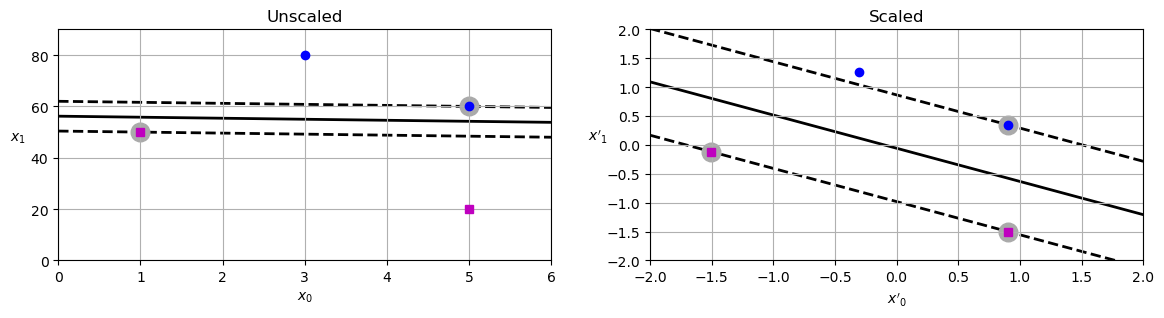

</center>

스케일링을 하지 않은 왼쪽 그래프에서는 수직축의 스케일이 수평축의 스케일보다 훨씬 커서 가장 넓은 도로가 거의 수평에 가깝다. 변수의 스케일을 조정하면 오른쪽 그래프처럼 결정 경계가 훨씬 좋아진다.

### 소프트 마진 분류

모든 샘플이 도로 바깥쪽에 올바르게 분류되어 있다면 이를 **하드 마진 분류(Hard margin classification)** 라고 한다. 하드 마진 분류에는 두 가지 문제점이 있다.  
- 1. 데이터가 선형적으로 분류될 수 있어야 제대로 작동한다.  
- 2. 이상치에 민감하다.

<center>

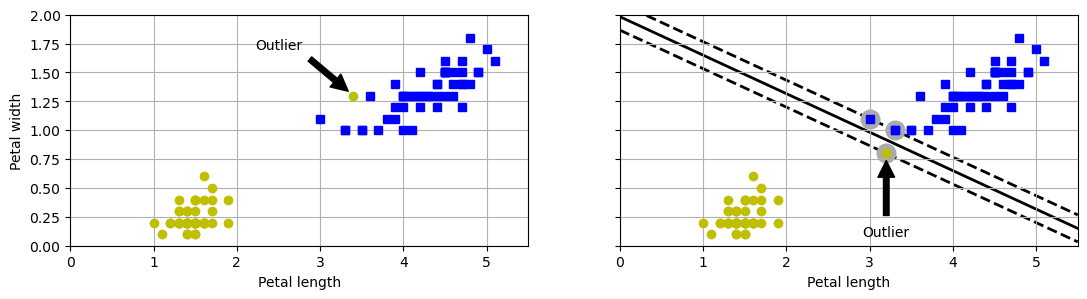

</center>

왼쪽 그래프에서는 하드 마진을 찾을 수 없다. 오른쪽 그래프의 결정 경계는 이상치가 없는 결정 경계와 매우 다르고 모델이 일반화될 것 같지 않다.

이런 문제를 피하려면 좀 더 유연한 모델이 필요하다. 도로의 폭을 가능한 한 넓게 유지하는 것과 **마진 오류**(샘플이 도로의 중간이나 아예 반대쪽에 있는 경우) 사이에 적절한 균형을 잡아야 한다. 이를 **소프트 마진 분류(soft margin classification)** 라고 한다.

사이킷런의 SVM 모델을 만들 때 규제 하이퍼파라미터 `C`를 포함하여 여러 하이퍼파라미터를 지정할 수 있다.

SVM의 `C`는 마진 오류의 허용 정도를 제어하는 하이퍼파라미터이며, 복잡도와 일반화 능력 사이의 균형을 조절한다.  

- 작은 `C` : 마진 오류를 어느 정도 허용함. 일반화가 잘 되지만 과소적합 될 수 있음  

- 큰 `C` : 마진 오류를 강하게 규제함. 성능이 증가할 수 있지만 과대적합 될 수 있음

<center>

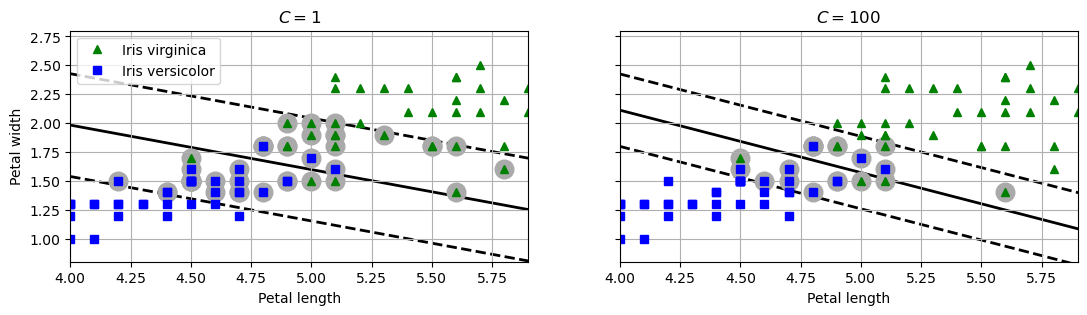

</center>

위의 그림에서 볼 수 있듯이, `C`를 줄이면 도로가 커지지만 더 많은 마진 오류가 발생한다. 즉, `C`를 줄이면 도로를 지지하는 서포트 벡터가 더 많아진다. 따라서 모델은 더 많은 샘플의 영향을 받아 더 단순하게 학습할 것이므로 과대적합의 위험이 감소한다. 하지만 `C`를 너무 줄이면 모델이 과소적합 될 것이다.

반대로 `C`가 증가하면 도로의 폭이 좁아지지만 마진 오류가 `C=1`보다 작은 것을 볼 수 있다.

다음 사이킷런 코드는 붓꽃 데이터셋을 불러오고 *Iris-Virginica* 품종을 감지하기 위해 선형 SVM 모델을 훈련한다. 이 파이프라인은 먼저 변수의 스케일을 변경한 다음 `C=1`인 `LinearSVM`을 사용한다.

In [3]:
iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)','petal width (cm)']].values
y = (iris.target == 2)

svm_clf = make_pipeline(StandardScaler(),
                        LinearSVC(C=1, random_state=42))

svm_clf.fit(X,y);

In [4]:
## 예측
X_new = [[5.5,1.7],[5.0,1.5]]
svm_clf.predict(X_new)

array([ True, False])

첫 번째 꽃은 *Iris-Virginica*로 분류되지만 두 번째 꽃은 그렇지 않다. SVM은 각 샘플과 결정 경계 사이의 거리를 측정하여 예측에 사용한다.

In [5]:
svm_clf.decision_function(X_new)

array([ 0.66163411, -0.22036063])

로지스틱 회귀와 달리 `LinearSVC`에는 클래스 확률을 추정하는 `predict_proba()` 메서드가 없다. `LinearSVC` 대신 다음에 볼 `SVC` 클래스를 사용하고 `probability=True`로 설정하면 훈련이 끝날 때 `SVM` 결정 함수 점수를 추정 확률에 매핑하기 위해 추가적인 모델을 훈련한다. 이렇게 하려면 5-fold 교차 검증을 사용하여 훈련 세트의 모든 샘플에 대해 Out-of-Sample 예측을 생성한 다음 로지스틱 회귀 모델을 훈련해야 하므로 훈련 속도가 상당히 느려진다. 그 이후 `predict_proba()` 및 `predict_log_proba()` 메서드를 사용할 수 있다.

---

## 5.2 비선형 SVM 분류

선형 SVM 분류기는 선형적으로 분류할 수 없는 데이터셋이 많다. 비선형 데이터셋을 다루는 한 가지 방법은 다항 변수와 같은 변수를 더 추가하는 것이다. 이렇게 하면 선형적으로 구분되는 데이터셋이 만들어진다.

다음 그림의 왼쪽 그래프는 하나의 변수 $x_1$를 가진 데이터셋이며, 왼쪽 데이터셋은 두 번째 변수인 $x_2=(x_1)^2$를 추가하여 만든 2차원 데이터셋이다.

<center>

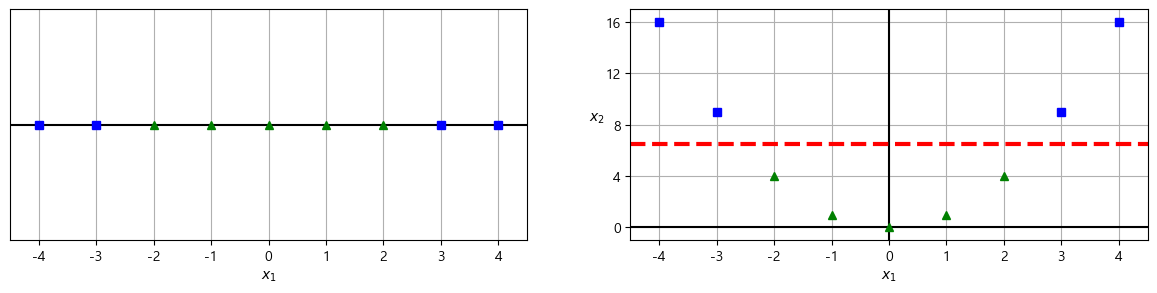

</center>

그림에서 볼 수 있듯이, 왼쪽 데이터셋은 선형적으로 분류할 수 없지만, 두 번째 변수를 추가하여 만들어진 데이터셋은 완벽하게 선형적으로 구분할 수 있다.

### 다항식 커널

`PolynomialFeatures`를 사용하여 다항 변수를 만들 수 있지만, 낮은 차수의 다항식은 복잡한 데이터셋을 잘 표현하지 못하고 높은 차수의 다항식은 굉장히 많은 변수를 추가하므로 모델을 느리게 만든다.

하지만 SVM을 사용할 땐 **커널 트릭(Kernel trick)** 이라는 수학적 기법을 적용할 수 있다. 커널 트릭은 실제로는 변수를 추가하지 않으면서 매우 높은 차수의 다항 변수를 많이 추가한 것과 같은 결과를 얻게 해준다. 즉, 어떤 변수도 추가하지 않기 때문에 엄청난 수의 변수 조합이 생기지 않는다. 이 기법은 `SVC` 파이썬 클래스에 구현되어 있다.

이를 사이킷런의 moons 데이터셋에 적용해본다. 이 데이터셋은 마주보는 두 개의 초승달 모양으로 데이터 포인트가 놓여 있는 이진 분류를 위한 작은 데이터셋이다. `make_moons()` 함수를 사용해 이 데이터셋을 만들 수 있다.

In [6]:
## 시각화 함수 코드
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

이 코드는 3차 다항식 커널을 사용해 SVM 분류기를 훈련시킨다.

In [7]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

from sklearn.svm import SVC

X,y = make_moons(n_samples=100,noise=0.15,random_state=42)

poly_kernel_svm_clf = make_pipeline(StandardScaler(),SVC(kernel='poly',degree=3,coef0=1,C=5))
poly_kernel_svm_clf.fit(X,y);

여기서 `coef0` 하이퍼파라미터는 모델이 높은 차수와 낮은 차수에 얼마나 영향을 받을지 조절한다. `coef0`가 크면 낮은 차수 항들의 상대적인 영향력이 커지고, 반대로 작으면 높은 차수 항들의 영향력이 커진다. `C`와 다르게 완전히 규제 하이퍼파라미터는 아니지만, 간접적으로 모델 복잡도와 일반화 능력에 영향을 주기에 **간접 규제** 역할을 한다.

다음 그림의 왼쪽은 바로 위에서 학습시킨 3차 다항식 커널을 사용한 SVM, 오른쪽은 10차 다항식 커널을 사용한 또 따른 SVM 분류기이다. 모델이 과대적합이라면 다항식의 차수를 줄이고, 반대로 과소적합이면 차수를 늘려야 한다.

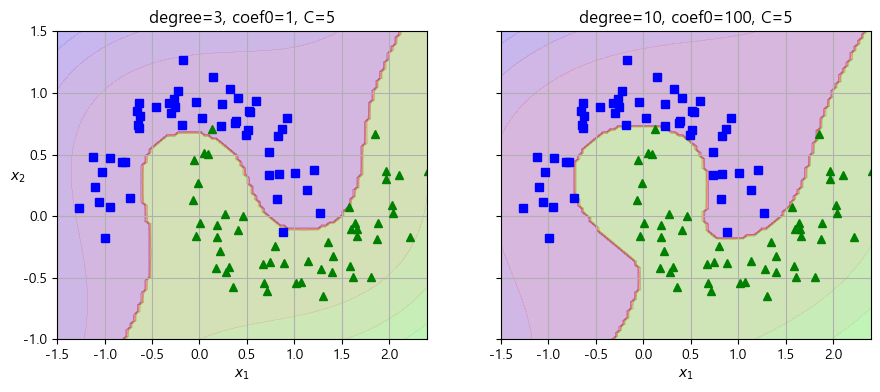

In [8]:
poly100_kernel_svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="poly", degree=10, coef0=100, C=5)
)
poly100_kernel_svm_clf.fit(X, y)

fig, axes = plt.subplots(ncols=2, figsize=(10.5, 4), sharey=True)

plt.sca(axes[0])
plot_predictions(poly_kernel_svm_clf, [-1.5, 2.45, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.4, -1, 1.5])
plt.title("degree=3, coef0=1, C=5")

plt.sca(axes[1])
plot_predictions(poly100_kernel_svm_clf, [-1.5, 2.45, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.4, -1, 1.5])
plt.title("degree=10, coef0=100, C=5")
plt.ylabel("")

plt.show()

### 유사도 특성

비선형 변수를 다루는 또 다른 기법은 각 샘플이 특정 **랜드마크**와 얼마나 닮았는지 측정하는 **유사도 함수**로 계산한 변수를 추가하는 것이다. 앞에서 본 1차원 데이터셋에 두 개의 랜드마크 $x_1=-2$와 $x_1=1$을 추가하고 $\gamma=0.3$인 가우스 **방사 기저 함수(Radial Basis Function,RBF)** 를 유사도 함수로 정의한다. 이 함수의 값은 랜드마크로부터 아주 멀리 떨어진 0부터 랜드마크와 같은 위치인 1까지 변화하며 종 모양으로 나타난다.

$$
RBF(x,l) = exp(-\gamma \times \left\| x-l  \right\|^2 )
$$

예를 들어 $x_1=-1$ 샘플을 살펴본다. 이 샘플은 첫 번째 랜드마크인 -2에서 1만큼 떨어져 있고 두 번째 랜드마크인 1에서 2만큼 떨어져 있다. 그러므로 새로 만든 변수는 다음과 같다.
$$
x_2=exp(-0.3 \times 1^2) \approx 0.74
$$

$$
x_3=exp(-0.3 \times 2^2) \approx 0.3
$$

<center>

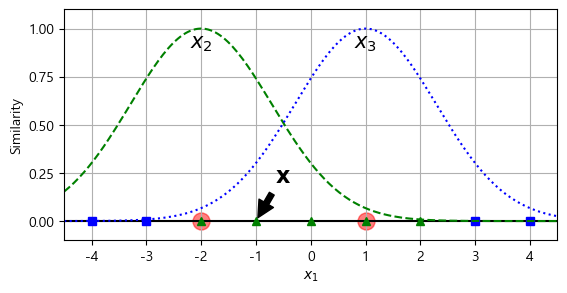

</center>

다음 그림은 원본 변수는 제거하고 변환된 데이터셋을 보여준다. 그림에서 알 수 있듯이 선형 분류가 가능해졌다.

<center>

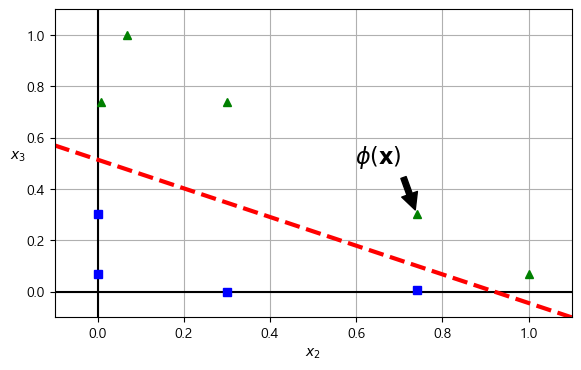

</center>

랜드마크는 어떻게 선택할까? 간단한 방법은 데이터셋에 있는 모든 샘플 위치에 랜드마크를 설정하는 것이다. 이렇게 하면 차원이 매우 커져 변환된 훈련 세트가 선형적으로 구분될 가능성이 높다. 하지만 훈련 세트에 있는 $n$개의 변수를 가진 $m$개의 샘플이 $m$개의 변수를 가진 $m$개 샘플로 변환되어 데이터셋이 너무 커진다.

### 가우스 RBF 커널

다항식 방식과 마찬가지로 유사도 방식도 머신러닝 알고리즘에 유용하게 사용될 수 있다. 추가 변수를 모두 계산하려면 연산 비용이 크게 증가한다. 훈련 세트가 큰 경우 더욱 문제가 된다. 여기서 **커널 트릭**을 사용하면 실제로 변수를 추가하지 않고 유사도 특성을 추가하는 것과 같은 비슷한 결과를 얻을 수 있다. 

가우스 RBF 커널을 사용한 SVC 모델을 만들어본다.

In [9]:
rbf_kernel_svm_clf = make_pipeline(StandardScaler(),
                                   SVC(kernel='rbf',gamma=5,C=0.001))

rbf_kernel_svm_clf.fit(X,y);

`gamma` 하이퍼파라미터는 데이터 포인트 간 거리의 영향력을 조절하는 하이퍼파라미터이다.

위의 유사도 그래프에서 만약 `gamma`를 줄이면 종 모양의 유사도 함수가 넓어져 상대적으로 멀리 떨어져 있는 값에도 작지 않은 유사도 가중치가 부여된다. 따라서 샘플이 넓은 범위에 걸쳐 영향을 주므로 결정 경계가 부드러워 진다.

반대로 `gamma`를 상승시키면 유사도 함수가 좁아져 각 샘플의 영향이 작아지며, 가까운 샘플들에게 높은 가중치가 부여되고, 멀리 떨어진 샘플의 영향력은 미미해진다. 따라서 결정 경계가 조금 더 불규칙해지고 각 샘플을 따라 구불구불하게 휘어진다.

<center>

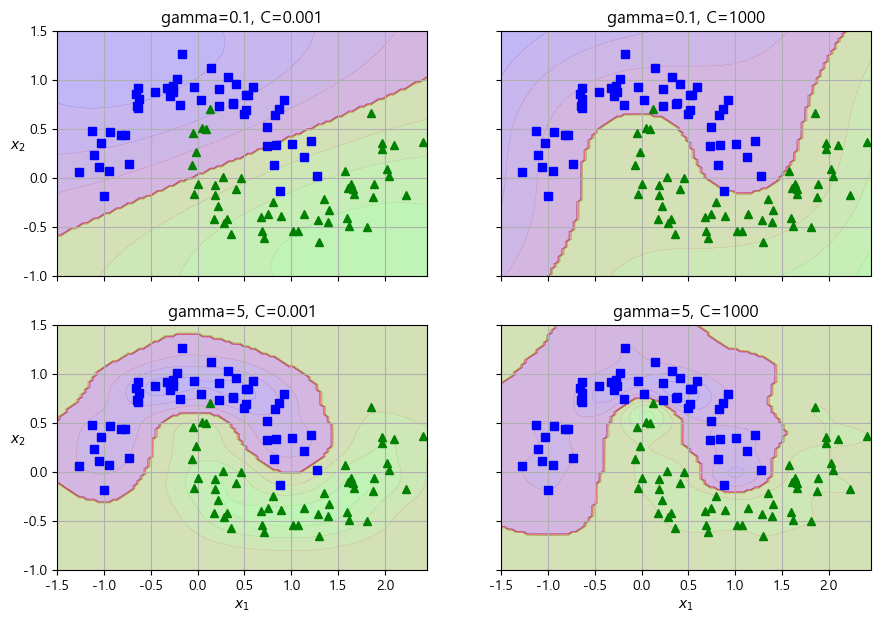

</center>

결국 하이퍼파라미터 `gamma`도 규제의 역할을 한다. 모델이 과대적합일 경우 감소시켜야 하고, 과소적합인 경우엔 증가시켜야 한다. 따라서 모델의 복잡도를 조절하려면 `gamma`와 `C` 하이퍼파라미터를 함께 조절하면서 최적의 조합을 찾아야 한다.

### 그 외 커널

그 외에 다양한 커널이 있지만 거의 사용되지 않는다. 문자열 커널, 문자열 서브시퀀스 커널, 레벤슈타인 거리 기반 커널과 같이 특정 데이터 구조에 특화되어 있는 커널 함수들이 있다.

사이킷런의 `SVC` 클래스에서 사용할 수 있는 커널은 `linear`,`poly`,`rbf`,`sigmoid` 4개의 커널이 있다. 또한 사용자 정의 커널을 사용하고 싶다면 `precomputed` 로 불러와 사용할 수도 있다.

참고로 `SVC(kernel='linear)`는 매우 느리므로 선형 SVM을 사용하려면 `LinearSVC`를 사용하는 것이 훨씬 좋다.

### 계산 복잡도

`LinearSVC` 클래스는 선형 SVM을 위해 최적화된 알고리즘을 구현한 `liblinear` 라이브러리를 기반으로 한다. 커널 트릭을 지원하지 않지만 훈련 샘플과 변수 수에 거의 선형적으로 늘어나는 계산 복잡도를 가지고 있다. 훈련 시간은 대략 $O(m \times n)$ 정도이다.

정밀도를 높이면 알고리즘의 수행 시간이 길어지는데, 이는 허용 오차 하이퍼파라미터 $\epsilon$으로 조절한다. 이는 사이킷런에서 매개변수 `tol`이다.

`SVC`는 커널 트릭 알고리즘을 구현한 `libsvm` 라이브러리를 기반으로 한다. 훈련 시간 복잡도는 보통 $O(m^2 \times n)$과 $O(m^3 \times n)$ 사이이다. 훈련 샘플 수가 커지면 엄청나게 느려진다. 따라서 중소규모의 비선형 훈련 세트에 이 알고리즘이 잘 맞는다. 하지만 변수의 수에 대해서는, 특히 각 샘플에 0이 아닌 변수가 몇 개 없는 경우인 **희소 변수(Sparse feature)** 에는 잘 확장된다. 이런 경우 알고리즘의 성능이 샘플이 가진 0이 아닌 변수의 평균 수에 거의 비례한다.

## 5.3 SVM 회귀

SVM을 분류가 아니라 회귀에 적용하기 위해선 목표를 바꿔야 한다. 일정한 마진 오류 안에서 두 클래스 간의 도로 폭이 최대가 되도록 하는 대신, SVM 회귀는 **제한된 마진 오류(도로 밖의 샘플)** 안에서 도로 안에 가능한 한 많은 샘플이 들어가도록 학습한다.

SVM 회귀 모델 클래스인 `SVR`과 `LinearSVR`에서 허용 오차는 `tol` 파라미터, 도로의 폭은 `epsilon` 파라미터를 사용하여 조절한다.

다음 그림은 랜덤 생성한 선형 데이터셋에 훈련시킨 두 개의 선형 SVM 회귀 모델을 보여준다. 왼쪽은 마진을 작게($\epsilon=0.5$), 다른 하나는 마진을 크게($\epsilon=1.2$) 만들었다.

In [10]:
from sklearn.svm import LinearSVR

np.random.seed(42)
X = 2 * np.random.rand(50, 1)
y = 4 + 3 * X[:, 0] + np.random.randn(50)

svm_reg = make_pipeline(StandardScaler(),
                        LinearSVR(epsilon=0.5, dual=True, random_state=42))
svm_reg.fit(X, y);

In [11]:
## 시각화 함수 코드
def find_support_vectors(svm_reg, X, y):
    y_pred = svm_reg.predict(X)
    epsilon = svm_reg[-1].epsilon
    off_margin = np.abs(y - y_pred) >= epsilon
    return np.argwhere(off_margin)

def plot_svm_regression(svm_reg, X, y, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(100, 1)
    y_pred = svm_reg.predict(x1s)
    epsilon = svm_reg[-1].epsilon
    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$", zorder=-2)
    plt.plot(x1s, y_pred + epsilon, "k--", zorder=-2)
    plt.plot(x1s, y_pred - epsilon, "k--", zorder=-2)
    plt.scatter(X[svm_reg._support], y[svm_reg._support], s=180,
                facecolors='#AAA', zorder=-1)
    plt.plot(X, y, "bo")
    plt.xlabel("$x_1$")
    plt.legend(loc="upper left")
    plt.axis(axes)

<center>

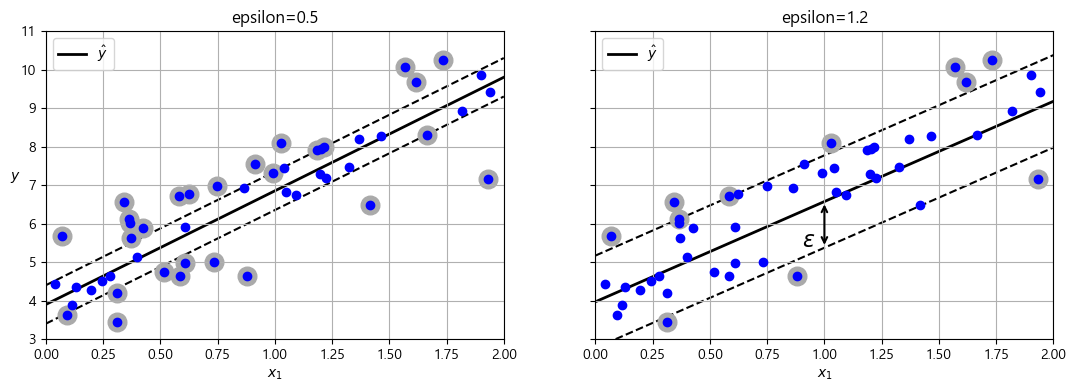

</center>

분류와 달리, **도로(마진 튜브)의 밖에 있는 샘플들이 서포트 벡터**이다. 서포트 벡터 회귀는 오차가 $\epsilon$ 이하면 무시한다. 즉, 오차가 마진 튜브의 밖에 있는 샘플에 대해서만 손실을 계산한다. 마진 안에서는 훈련 샘플이 추가되어도 모델의 예측에는 큰 영향이 없다. 이러한 특성으로 인해 **$\boldsymbol{\epsilon}$에 민감하지 않다** 라고 한다.

`epsilon`의 크기가 작으면, $\epsilon$ 튜브의 폭이 작아지며 서포트 벡터의 수가 늘어나 모델이 규제된다.

사이킷런의 `LinearSVR`을 사용해 선형 SVM 회귀를 적용해본다. 다음 코드는 위의 왼쪽 그래프에 해당하는 모델을 만든다.

In [12]:
from sklearn.svm import LinearSVR

np.random.seed(42)
X = 2 * np.random.rand(50, 1)
y = 4 + 3 * X[:, 0] + np.random.randn(50)

svm_reg = make_pipeline(StandardScaler(),
                        LinearSVR(epsilon=0.5, dual=True, random_state=42))
svm_reg.fit(X, y);


비선형 회귀를 하려면 커널 SVM 모델을 사용한다. 다음은 임의의 2차 방정식 형태의 훈련 세트에 2차 다항 커널을 사용한 SVM 회귀를 보여준다.

<center>

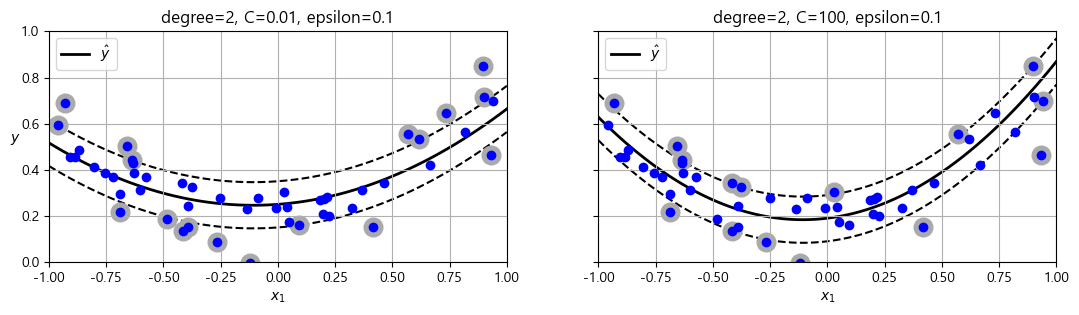

</center>

다음 코드는 사이킷런의 `SVR`을 사용해 위의 왼쪽 그래프에 해당하는 모델을 만든다.

In [13]:
from sklearn.svm import SVR

np.random.seed(42)
X = 2 * np.random.rand(50, 1) - 1
y = 0.2 + 0.1 * X[:, 0] + 0.5 * X[:, 0] ** 2 + np.random.randn(50) / 10

svm_poly_reg = make_pipeline(StandardScaler(),
                             SVR(kernel="poly", degree=2, C=0.01, epsilon=0.1))
svm_poly_reg.fit(X, y);

`SVR`은 `SVC`의 회귀 버전이고 `LinearSVR`은 `LinearSVC`의 회귀 버전이다.

`SGDClassifier`와 `SGDRegressor` 클래스에서 규제 하이퍼파라미터(`alpha` 및 `penalty`)와 `learning_rate`를 조정하여 선형 SVM 분류/회귀 모델을 만들 수 있다. 훈련을 위해 점진적으로 학습이 가능하고 메모리를 거의 사용하지 않는 확률적 경사하강법을 사용하므로 RAM에 맞지 않는 대규모 데이터셋에서 훈련할 수 있다. 또한 계산 복잡도가 $O(m \times n)$이므로 확장성이 뛰어나다. 다만 커널은 사용할 수 없다.

---

## 5.4 SVM 이론

지금까지는 편향 $\theta_0$와 입력 변수 가중치 $\theta_1 \sim \theta_n$을 포함하여 모든 모델 파라미터를 하나의 벡터 $\boldsymbol{\theta}$에 포함하고 이를 위해 모든 샘플에 절편(편향) $x_0=1$를 추가했다. 널리 사용되는 또 다른 방법은 절편 $b$($=\theta_0$)와 변수 가중치 벡터 $\boldsymbol{\theta}(\theta_1 \sim \theta_n )$을 분리하는 것이다. 이 경우 절편 $x_0$를 추가할 필요가 없다. 앞으로 해당 표기를 사용한다.  
선형 SVM의 결정 함수는 $\mathbf{w^Tx}+b = w_1x_1 + \cdots + w_nx_n +b$가 된다.

선형 SVM 분류기 모델은 단순히 결정함수 $\mathbf{w^Tx}+b = w_1x_1 + \cdots + w_nx_n +b$을 계산해서 새로운 샘플 $\mathbf{x}$의 클래스를 예측한다. 결과값이 0보다 크면 $\hat{y}$는 양성 클래스(1)이 되고, 그렇지 않으면 음성 클래스(0)가 된다. 따라서 선형 SVM 분류기로 예측하는 것은 매우 간단하다.

이제 모델 훈련 방식을 살펴본다. **마진 오류 수를 제한**하면서 동시에 **마진을 가능한 한 넓게 만드는** 가중치 벡터 $\mathbf{w}$와 절편 $b$를 찾아야 한다.

### 마진 크기

마진의 너비를 더 넓히려면 $\mathbf{w}$를 더 작게 만들어야 한다. 다음 그래프는 서로 다른 가중치를 가진 마진의 예시이다.

<center>

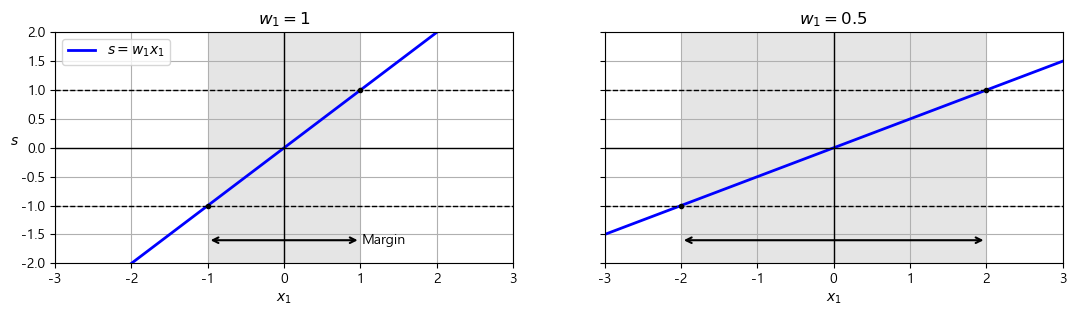

</center>

왼쪽 그래프에서 가중치 $w_1$은 1이다. 따라서 $w_1x_1$이 -1과 1이 되는 $x_1$은 동일하게 -1과 1이다. 따라서 마진의 크기는 2이다. 오른쪽 그래프에서의 가중치 $w_1$은 0.5이므로 $w_1x_1$이 -1과 1이 되는 $x_1$은 -2와 2이고, 마진의 크기는 4로 가중치가 클 때보다 증가했다. 따라서 마진을 넓게 하려면 작은 가중치를 부여해야 한다. 여기서 $b$는 마진의 크기에 영향을 미치지 않는다. 이 값을 조정해도 마진 크기에는 영향을 미치지 않고 위치만 이동한다.

### 마진 오류

마진의 오류를 줄이기 위해선 결정 함수가 모든 양성 훈련 샘플에서는 1보다 커야 하고 음성 훈련 샘플에서는 -1보다 작아야 한다. 음성 샘플($y^{(i)}=0$) 일 때 $t^{(i)}=-1$로, 양성 샘플($y^{(i)}=1$)일 때 $t^{(i)}=1$로 정의하면 앞서 말한 제약 조건을 모든 샘플에서 다음과 같이 표현할 수 있다.
$$
t^{(i)}(\mathbf{w^Tx^{(i)}}+1) \ge 1
$$

그러므로 하드 마진 선형 SVM 분류기의 목적 함수를 다음과 같이 **제약이 있는 최적화 문제**로 표현할 수 있다.
$$
\underset{\mathbf{w},b}{\min} \frac{1}{2} \mathbf{w^Tw}\ \ subject\ to\ \ t^{(i)}(\mathbf{w^Tx^{(i)}}+1) \ge 1
$$
$$
i=1,2,...,m
$$

$\mathbf{w}$의 $norm$인 $\left\| \mathbf{w} \right\|$ 를 최소화하는 대신 $\frac{1}{2}\left\| \mathbf{w} \right\|^2$ 인 $\frac{1}{2}\mathbf{w^Tw}$를 최소화한다. 최적화 알고리즘은 미분할 수 있는 함수에서 잘 작동하는데, $\left\| \mathbf{w} \right\|$은 $ \mathbf{w}=0$에서 분모가 0이 되므로 도함수가 정의되지 않는다. 반면 $\frac{1}{2}\left\| \mathbf{w} \right\|^2$은 깔끔하고 간단하게 미분이 된다. 미분 결과는 $\mathbf{w}$이다.

소프트 마진 분류기의 목적 함수를 구성하기 위해 각 샘플에 대해 **슬랙 변수(slack variable)** $\boldsymbol{\zeta^{(i)}} \ge 0$ 을 도입한다. $\zeta^{(i)}$는 $i$번째 샘플이 얼마나 마진을 위반할지 정한다.

이는 두 개의 **상충되는 목표**를 가지고 있다. 마진 오류를 최소화하기 위해 가능한 한 슬랙 변수의 값을 작게 만드는 것과 마진을 크게 하기 위해 $\frac{1}{2}\mathbf{w^Tw}$를 가능한 한 작게 만들어야 한다. 여기에서 하이퍼파라미터 $C$를 사용한다. $C$는 두 목표 사이의 트레이드오프를 정의한다. 따라서 결국에 다음과 같은 제약을 가진 최적화 문제가 된다.

#### 분류 목적 함수
$$
\underset{\mathbf{w},b,\zeta}{\min} \frac{1}{2} \mathbf{w^Tw}+C\sum_{i=1}^{m}\zeta^{(i)} \ \ subject\ to\ \ t^{(i)}(\mathbf{w^Tx^{(i)}}+1) \ge 1-\zeta^{(i)}
$$
$$
i=1,2, \dots ,m,\ \zeta^{(i)} \ge 0
$$

#### 회귀 목적 함수
회귀에서는 결정 경계의 양쪽으로 모든 샘플을 담기 위한 마진의 오차 폭을 두 개의 슬랙 변수 $\zeta,\zeta^*$라고 할 때 목적 함수는 다음과 같다.

$$
\underset{\mathbf{w}, b, \zeta, \zeta^*}{\min} \ \frac{1}{2} \mathbf{w}^\top\mathbf{w} + C \sum_{i=1}^{m} \left( \zeta^{(i)} + \zeta^{*(i)} \right)
$$

$$
\text{subject to } 
\begin{cases}
y^{(i)} - (\mathbf{w}^\top\mathbf{x}^{(i)} + b) \le \varepsilon + \zeta^{(i)} \\
(\mathbf{w}^\top\mathbf{x}^{(i)} + b) - y^{(i)} \le \varepsilon + \zeta^{*(i)} \\
\zeta^{(i)},\ \zeta^{*(i)} \ge 0
\end{cases}
\quad i = 1, 2, \dots, m
$$

하드 마진과 소프트 마진 문제는 모두 선형적인 제약 조건이 있는 볼록 함수의 이차 최적화 문제이다. 이런 문제를 **Quadratic programming(QP)** 문제라고 한다. 여러 가지 기법으로 QP 문제를 푸는 알고리즘이 있다.

SVM을 훈련하는 한 가지 방법은 QP Solver를 사용하는 것이고, 또 다른 방법은 경사하강법을 사용하여 **힌지 손실(hinge loss)** 또는 **제곱 힌지 손실(sqaure hinge loss)** 를 최소화하는 것이다.  
다음 그래프는 분류에서의 힌지 손실(왼쪽)과 제곱 힌지 손실 함수(오른쪽)를 보여준다.

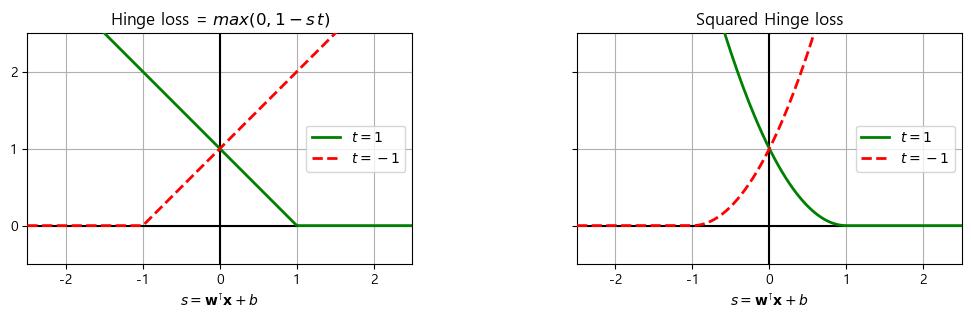

In [18]:
s = np.linspace(-2.5, 2.5, 200)
hinge_pos = np.where(1 - s < 0, 0, 1 - s)  # max(0, 1 - s)
hinge_neg = np.where(1 + s < 0, 0, 1 + s)  # max(0, 1 + s)

titles = (r"Hinge loss = $max(0, 1 - s\,t)$", "Squared Hinge loss")

fix, axs = plt.subplots(1, 2, sharey=True, figsize=(13, 3))

for ax, loss_pos, loss_neg, title in zip(
        axs, (hinge_pos, hinge_pos ** 2), (hinge_neg, hinge_neg ** 2), titles):
    ax.plot(s, loss_pos, "g-", linewidth=2, zorder=10, label="$t=1$")
    ax.plot(s, loss_neg, "r--", linewidth=2, zorder=10, label="$t=-1$")
    ax.grid(True)
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    ax.set_xlabel(r"$s = \mathbf{w}^\intercal \mathbf{x} + b$")
    ax.axis([-2.5, 2.5, -0.5, 2.5])
    ax.legend(loc="center right")
    ax.set_title(title)
    ax.set_yticks(np.arange(0, 2.5, 1))
    ax.set_aspect("equal")

plt.show()



위의 그림은 힌지 손실과 제곱 힌지 손실 함수를 보여준다. 양성 클래스 샘플 $\mathbf{w}$가 주어졌을 때($t=1$) 결정 함수의 출력 $s=\mathbf{w^Tx}+b$이  1보다 크면 손실이 0이다. 마찬가지로 음성 클래스 샘플($t=-1$)이 주어졌을 때, $s \le 1$이면 손실이 0이다. **두 경우 모두 샘플이 마진에서 벗어나 각 클래스 쪽으로 정분류되어 있는 경우**를 의미한다. 하지만 샘플이 **마진 안에 포함되거나, 해당 클래스에서 반대로 멀어질수록 손실이 커진다.** 제곱 손실이 이상치에 더 민감하게 반응한다.

다음으로 회귀에서의 손실을 살펴본다.

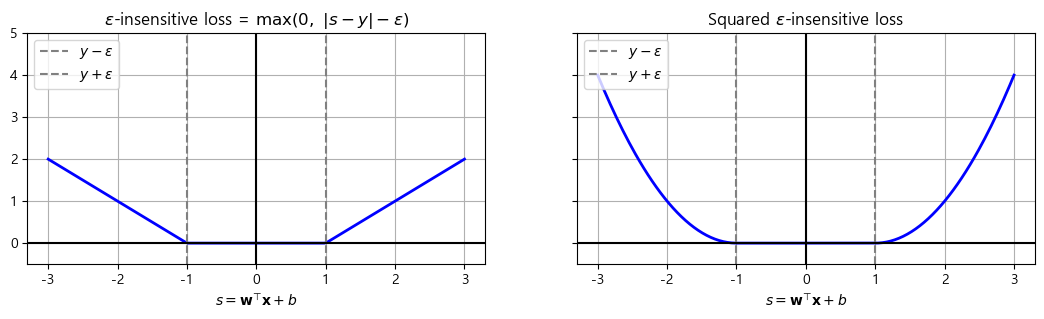

In [24]:
s = np.linspace(-3, 3, 200)  # 예측값 s = f(x)
y_true = 0                   # 실제값 y = 0 (기준선)
epsilon = 1.0                # 마진 튜브 폭

# ε-insensitive loss
loss_epsilon = np.maximum(0, np.abs(s - y_true) - epsilon)
loss_epsilon_squared = loss_epsilon**2

titles = (
    r"$\varepsilon$-insensitive loss = $\max(0,\ |s - y| - \varepsilon)$", 
    r"Squared $\varepsilon$-insensitive loss"
)

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(13, 3))

for ax, loss, title in zip(
    axs, (loss_epsilon, loss_epsilon_squared), titles):
    
    ax.plot(s, loss, "b", linewidth=2)
    ax.axvline(x=y_true - epsilon, color='gray', linestyle='--', label=r"$y - \varepsilon$")
    ax.axvline(x=y_true + epsilon, color='gray', linestyle='--', label=r"$y + \varepsilon$")
    ax.axvline(x=y_true, color='k', linestyle='-')
    ax.axhline(y=0, color='k')
    ax.set_xlabel(r"$s = \mathbf{w}^\top \mathbf{x} + b$")
    ax.set_title(title)
    ax.set_ylim(-0.5, 5)
    ax.grid(True)
    ax.legend(loc="upper left")

plt.show()

SVM 회귀에서는 힌지 손실이 아닌 **$\boldsymbol{\epsilon}$-insensitive 손실**을 사용한다. 예측값이 실제 값에서 $\epsilon$ 이내에 있으면 손실은 0이지만, 해당 범위를 벗어나면 그 차이만큼 손실이 발생한다.

기본적으로 `LinearSVC`,`LinearSVR`은 제곱 힌지, 제곱 $\epsilon-insensitive$ 손실을 사용한다. `SGDClassifier`,`SGDRegressor`는 힌지와 제곱 $\epsilon-insensitive$ 손실을 사용한다. 하지만 이 클래스들 모두 `loss` 파라미터에서 제곱 손실 함수들을 지정하여 사용할 수 있다.

`SVC`,`SVR`은 일반적인 힌지와 제곱 $\epsilon-insensitive$ 손실을 최소화하는 것과 유사한 솔루션을 찾는다. 두 클래스는 손실 함수를 따로 정의할 수 없다.

## 5.5 쌍대 문제

다음으로 선형 SVM 분류기를 훈련하는 또 다른 방법인 쌍대 문제를 살펴본다. **원 문제(primal problem)** 라고 하는 제약이 있는 최적화 문제가 주어지면 **쌍대 문제(dual problem)** 라고 하는 깊게 관련된 다른 문제로 표현할 수 있다. 일반적으로 쌍대 문제의 해는 원 문제 해의 하한값이지만 어떤 조건하에서는 원 문제와 똑같은 해를 제공한다.  
**목적 함수가 볼록 함수이고, 부등식 제약 조건이 연속 미분 가능하면서 볼록 함수인 경우** 해가 같아지는데, SVM 문제는 이 조건을 만족시킨다. 따라서 원 문제 또는 쌍대 문제 중 하나를 선택하여 풀 수 있으며 둘 다 같은 해를 제공한다.

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● Tip</strong><br>
    <code>LinearSVC</code>,<code>LinearSVR</code>의 파라미터 <code>dual</code>의 기본값 <code>True</code>에서 <code>False</code>로 바꾸면 원 문제를 선택한다. <code>SVC</code>,<code>SVR</code>은 쌍대 문제만 푼다.
    </div>

다음 식이 선형 SVM 목적 함수의 쌍대 형식이다.
$$
\underset{\alpha}{\min}\frac{1}{2}\sum_{i=1}^{m}\sum_{j=1}^{m}\alpha^{(i)}\alpha^{(j)}t^{(i)}t^{(j)}\mathbf{x^{(i)^T}x^{(j)}}-\sum_{i=1}^{m}\alpha^{(i)}
$$

$$
subject\ to\ \alpha^{(i)} \ge 0,\ \sum_{i=1}^{m}\alpha^{(i)}t^{(i)}=0
$$

QP Solver를 사용해 이 식을 최소화하는 벡터 $\boldsymbol{\hat{\alpha}}$를 찾았다면 다음 식을 사용해 원 문제의 식을 최소화하는 $\hat{\mathbf{w}}$와 $\hat{b}$를 계산할 수 있다. 여기서 $n_s$는 서포트 벡터의 개수를 나타낸다.

$$
\hat{\mathbf{w}} = \sum_{i=1}^{m}\hat{\alpha}^{(i)}t^{(i)}\mathbf{x^{(i)}}
$$
$$
\hat{b}=\frac{1}{n_s}\sum_{i=1}^{m}(t^{(i)}-\hat{\mathbf{w}}^T\mathbf{x}^{(i)})

훈련 샘플 수가 변수의 수보다 작을 땐 원 문제보다 쌍대 문제를 푸는 것이 더 빠르다. 무엇보다도, 쌍대 문제는 원 문제에서는 적용이 안되는 **커널 트릭이 가능하다.**

### 커널 SVM

커널 트릭에 대해 더 자세히 설명한다. 2차원 데이터셋에 2차 다항식 변환을 적용하고 선형 SVM 분류기를 변환된 훈련 세트에 적용한다고 가정해본다. 다음 식이 우리가 적용하고자 하는 2차 다항식 매핑 함수 $\phi$이다.
$$
\phi(\mathbf{x})=\phi \begin{pmatrix}x_1 \\x_2\end{pmatrix} = \begin{pmatrix}x_1^2 \\\sqrt2x_1x_2 \\x_2^2\end{pmatrix}
$$

변환된 벡터는 2차원에서 3차원으로 증가했다. 두 개의 2차원 벡터 $\mathbf{a}$와 $\mathbf{b}$에 2차 다항식 매핑을 적용한 다음 내적을 적용해본다.
$$
\phi(\mathbf{a})^T\phi(\mathbf{b})= \begin{pmatrix}a_1^2 \\\sqrt2a_1a_2 \\a_2^2\end{pmatrix}^\mathbf{T}\begin{pmatrix}b_1^2 \\\sqrt2b_1b_2 \\b_2^2\end{pmatrix} = a_1^2b_1^2 + 2a_1b_1a_2b_2+a_2^2b_2^2=(a_1b_1+a_2b_2)^2= \begin{pmatrix}a_1 \\a_2 \\\end{pmatrix}^{\mathbf{T}}\begin{pmatrix}b_1 \\b_2 \\\end{pmatrix}=(\mathbf{a^Tb})^2
$$

**변환된 벡터의 내적이 기존 벡터 간 내적의 제곱과 같다.** 모든 훈련 샘플에 변환 $\phi$를 적용하면 쌍대 문제에 내적 $\phi(\mathbf{x}^{(i)})^T\phi(\mathbf{x}^{(j)})$가 포함된다. 하지만 $\phi$가 2차 다항식 변환이라면 변환된 벡터의 내적을 간단하게 $(\mathbf{x}^{(i)^T}\mathbf{x}^{(j)})^2$로 바꿀 수 있다. 그래서 실제 훈련 샘플을 변환할 필요가 전혀 없다. 결과값은 훈련 샘플을 힘들게 변환해서 선형 SVM 알고리즘을 적용하는 것과 완전히 같다. 하지만 이 커널 트릭이 계산량 측면에서 훨씬 효율적이다.

함수 $K(\mathbf{a,b})=(\mathbf{a^Tb})^d$을 $d$차 다항식 커널이라고 부른다. 머신러닝에서 **커널**은 변환 $\phi$를 계산하지 않고 원래 벡터 $\mathbf{a}$와 $\mathbf{b}$에 기반하여 내적 $\phi(\mathbf{a})^T\phi(\mathbf{b})$를 계산할 수 있는 함수이다. 다음은 많이 사용되면서 사이킷런의 `SVC`, `SVR`에서 사용할 수 있는 커널들이다.

$$
\begin{aligned}
\text{Linear} \quad & K(\mathbf{a}, \mathbf{b}) = \mathbf{a}^\top \mathbf{b} \\
\text{Polynomial (degree } d\text{)} \quad & K(\mathbf{a}, \mathbf{b}) = (\gamma\, \mathbf{a}^\top \mathbf{b} + r)^d \\
\text{Gaussian RBF} \quad & K(\mathbf{a}, \mathbf{b}) = \exp(-\gamma \|\mathbf{a} - \mathbf{b}\|^2) \\
\text{Sigmoid} \quad & K(\mathbf{a}, \mathbf{b}) = \tanh(\gamma\, \mathbf{a}^\top \mathbf{b} + r)
\end{aligned}
$$


### 머서의 정리

머서의 정리(Mercer's Theorem)은 **어떤 함수(변환)가 커널 트릭에 사용할 수 있는 '합법적인' 커널인지 판단하는 기준을 제공**한다.

#### 1. 대칭성(Symmetry)  
$$
K(\mathbf{a,b})=K(\mathbf{b,a})
$$

#### 2. 양의 정부호(Positive Semi-Definiteness,PSD)
모든 입력 변수 $\mathbf{x_1,\cdots,x_n}$에 대해서 커널 행렬 $K \in \mathbb{R}^{n \times n}$을 $K_{ij}=K(\mathbf{x_i,x_j})$로 정의했을 때 모든 실수 벡터 $\mathbf{c}=(c_1,\cdots,c_n)^T \in \mathbb{R}^n$에 대해서 다음 조건이 성립해야 한다.
$$
\mathbf{c}^TK\mathbf{c}=\sum_{i=1}^{n}\sum_{j=1}^{n}c_ic_jK(\mathbf{x_i,x_j}) \ge 0
$$

따라서 위의 조건을 만족하는 함수는 커널 트릭에 사용할 수 있다.